# WD+WD Figure 3 — ΔM vs Δt_cool

Reproduces Figure 3 from Heintz et al. (2024, WD+WD paper):  
mass difference vs cooling age difference for wide WD+WD pairs,  
split by spectral type combination, testing consistency with a monotonic IFMR.

**Convention (Heintz)**: WD1 is the *more massive* star (M₁ ≥ M₂), so ΔM = M₁ − M₂ ≥ 0 always.  
A monotonic IFMR predicts Δt_cool = t_cool,1 − t_cool,2 > 0 (more massive WD had a shorter-lived  
progenitor → longer cooling age for the same total age).  
**Inconsistent** = 1σ inconsistent with τ_c1 > τ_c2, i.e. Δt_cool + σ < 0.

Requires `ages.pqt` produced by `stitch.py` (includes `SpType` and `pop_type` columns).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from astropy.table import Table

plt.style.use('stefan.mplstyle')
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage[T1]{fontenc}\usepackage{lmodern}\usepackage{amsmath}",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

## Load data

In [2]:
# WD ages with SpType from stitch.py output
ages = pd.read_parquet('../data/ages.pqt')
ages_old = pd.read_parquet('~/observational/misc/ageabundance/data/omnidwarf/omnidwarf.pqt')
ages_old = ages_old[ages_old.sourceid.isin(ages.sourceid)]

data = pd.read_parquet('../data/widebinary/widebinary_fluxes.pqt')
data2 = pd.read_parquet('../data/widebinary/wdms_widebinaries.pqt')

ages = pd.merge(data, ages, left_on="GaiaEDR3", right_on="sourceid")

ngf = pd.read_parquet("~/observational/catalogs/nicola_wds/ngf21_wds.pqt")
ngf = ngf[ngf.GaiaEDR3.isin(ages.sourceid)]

print(f'WDs in sample: {len(ages)}')
print(f'With SpType: {ages["SpType"].notna().sum()}')
print(ages['SpType'].value_counts().head(10))

WDs in sample: 8416
With SpType: 8237
SpType
DA     6209
DA:     631
DB      442
DC      383
DC:     331
DZ       66
DQ       58
DB:      43
DZ:      43
DQ:      22
Name: count, dtype: int64


In [3]:
# El-Badry wide binary catalog — WD+WD pairs only, high-confidence
wb = pd.read_parquet('/home/arseneau/observational/catalogs/elbadry_widebinary.pqt')
wdwd = wb[(wb['binary_type'] == b'WDWD') & (wb['R_chance_align'] < 0.1)].copy()
print(f'WD+WD pairs (R_chance_align < 0.1): {len(wdwd)}')

s = set(ages['sourceid'])
mask = wdwd['source_id1'].isin(s) & wdwd['source_id2'].isin(s)
wdwd = wdwd[mask].copy()
print(f'WD+WD pairs with both in our sample: {len(wdwd)}')

WD+WD pairs (R_chance_align < 0.1): 1390
WD+WD pairs with both in our sample: 500


## Build pair table

In [4]:
age_cols = ['sourceid', 'mass', 'mass_hi', 'mass_lo', 'teff_best',
            'log_age_cool', 'log_age_cool_hi', 'log_age_cool_lo',
            'log_age',      'log_age_hi',      'log_age_lo',
            'SpType']

def merge_component(wdwd_df, id_col, suffix):
    return wdwd_df.merge(
        ages[age_cols].rename(columns={c: f'{c}{suffix}' for c in age_cols if c != 'sourceid'}),
        left_on=id_col, right_on='sourceid', how='left'
    ).drop('sourceid', axis=1)

pairs = merge_component(wdwd[['source_id1', 'source_id2', 'R_chance_align']].copy(), 'source_id1', '_1')
pairs = merge_component(pairs, 'source_id2', '_2')

print(f'Pairs: {len(pairs)}')
print(f'Both have log_age_cool: {pairs[["log_age_cool_1","log_age_cool_2"]].notna().all(axis=1).sum()}')
print(f'Both have log_age:      {pairs[["log_age_1","log_age_2"]].notna().all(axis=1).sum()}')

Pairs: 500
Both have log_age_cool: 500
Both have log_age:      142


In [5]:
# Enforce Heintz convention: WD1 = more massive star (M1 >= M2)
swap_cols = [c.replace('_1', '') for c in pairs.columns if c.endswith('_1')]
needs_swap = pairs['mass_2'] > pairs['mass_1']
print(f'Pairs swapped to enforce M1 >= M2: {needs_swap.sum()}')

for col in swap_cols:
    tmp = pairs.loc[needs_swap, f'{col}_1'].copy()
    pairs.loc[needs_swap, f'{col}_1'] = pairs.loc[needs_swap, f'{col}_2']
    pairs.loc[needs_swap, f'{col}_2'] = tmp

Pairs swapped to enforce M1 >= M2: 254


In [6]:
def log_to_gyr(log_age_yr):
    """Convert log10(yr) to Gyr."""
    return 10**(log_age_yr - 9)

for i in ['1', '2']:
    for base in ['log_age_cool', 'log_age']:
        pairs[f't_{base}_{i}']    = log_to_gyr(pairs[f'{base}_{i}'])
        pairs[f't_{base}_hi_{i}'] = log_to_gyr(pairs[f'{base}_hi_{i}'])
        pairs[f't_{base}_lo_{i}'] = log_to_gyr(pairs[f'{base}_lo_{i}'])
        pairs[f'e_t_{base}_{i}']  = (pairs[f't_{base}_hi_{i}'] - pairs[f't_{base}_lo_{i}']) / 2

    pairs[f'e_mass_{i}'] = (pairs[f'mass_hi_{i}'] - pairs[f'mass_lo_{i}']) / 2

pairs['dM']   = pairs['mass_1'] - pairs['mass_2']
pairs['e_dM'] = np.sqrt(pairs['e_mass_1']**2 + pairs['e_mass_2']**2)

for base in ['log_age_cool', 'log_age']:
    pairs[f'd_{base}']   = pairs[f't_{base}_1']   - pairs[f't_{base}_2']
    pairs[f'e_d_{base}'] = np.sqrt(pairs[f'e_t_{base}_1']**2 + pairs[f'e_t_{base}_2']**2)

pairs['dtcool']   = pairs['d_log_age_cool']
pairs['e_dtcool'] = pairs['e_d_log_age_cool']
pairs['dtot']     = pairs['d_log_age']
pairs['e_dtot']   = pairs['e_d_log_age']

valid_cool = pairs[['dM', 'dtcool', 'e_dtcool']].notna().all(axis=1)
valid_tot  = pairs[['dM', 'dtot',   'e_dtot'  ]].notna().all(axis=1)
print(f'Pairs with finite dM and dtcool: {valid_cool.sum()}')
print(f'Pairs with finite dM and dtot:   {valid_tot.sum()}')
assert (pairs.loc[valid_cool, 'dM'] >= 0).all(), 'dM should be non-negative after swap'

Pairs with finite dM and dtcool: 500
Pairs with finite dM and dtot:   142


## Spectral type classification

In [7]:
def stype_flags(stype_series):
    """Return (is_DA, is_DB, is_DC) boolean Series."""
    st = stype_series.fillna('').str.upper().str.replace(':', '', regex=False).str.strip()
    is_DA = st.str.startswith('DA') & ~st.str.startswith('DAB')
    is_DB = st.str.startswith('DB') | st.str.startswith('DAB') | st.str.startswith('DBA')
    is_DC = st.str.startswith('DC')
    return is_DA, is_DB, is_DC

is_DA1, is_DB1, is_DC1 = stype_flags(pairs['SpType_1'])  # more massive
is_DA2, is_DB2, is_DC2 = stype_flags(pairs['SpType_2'])  # less massive

panel_masks = {
    'DA+DA': is_DA1  &  is_DA2,
    'DA+DB': (is_DA1 &  is_DB2) | (is_DB1 &  is_DA2),
    'DA+DC': (is_DA1 &  is_DC2) | (is_DC1 &  is_DA2),
    'DC+DC':  is_DC1 &  is_DC2,
}

for label, mask in panel_masks.items():
    n = (mask & valid_cool).sum()
    print(f'{label}: {n} pairs with finite cooling ages')

DA+DA: 351 pairs with finite cooling ages
DA+DB: 25 pairs with finite cooling ages
DA+DC: 80 pairs with finite cooling ages
DC+DC: 11 pairs with finite cooling ages


## Figure 3

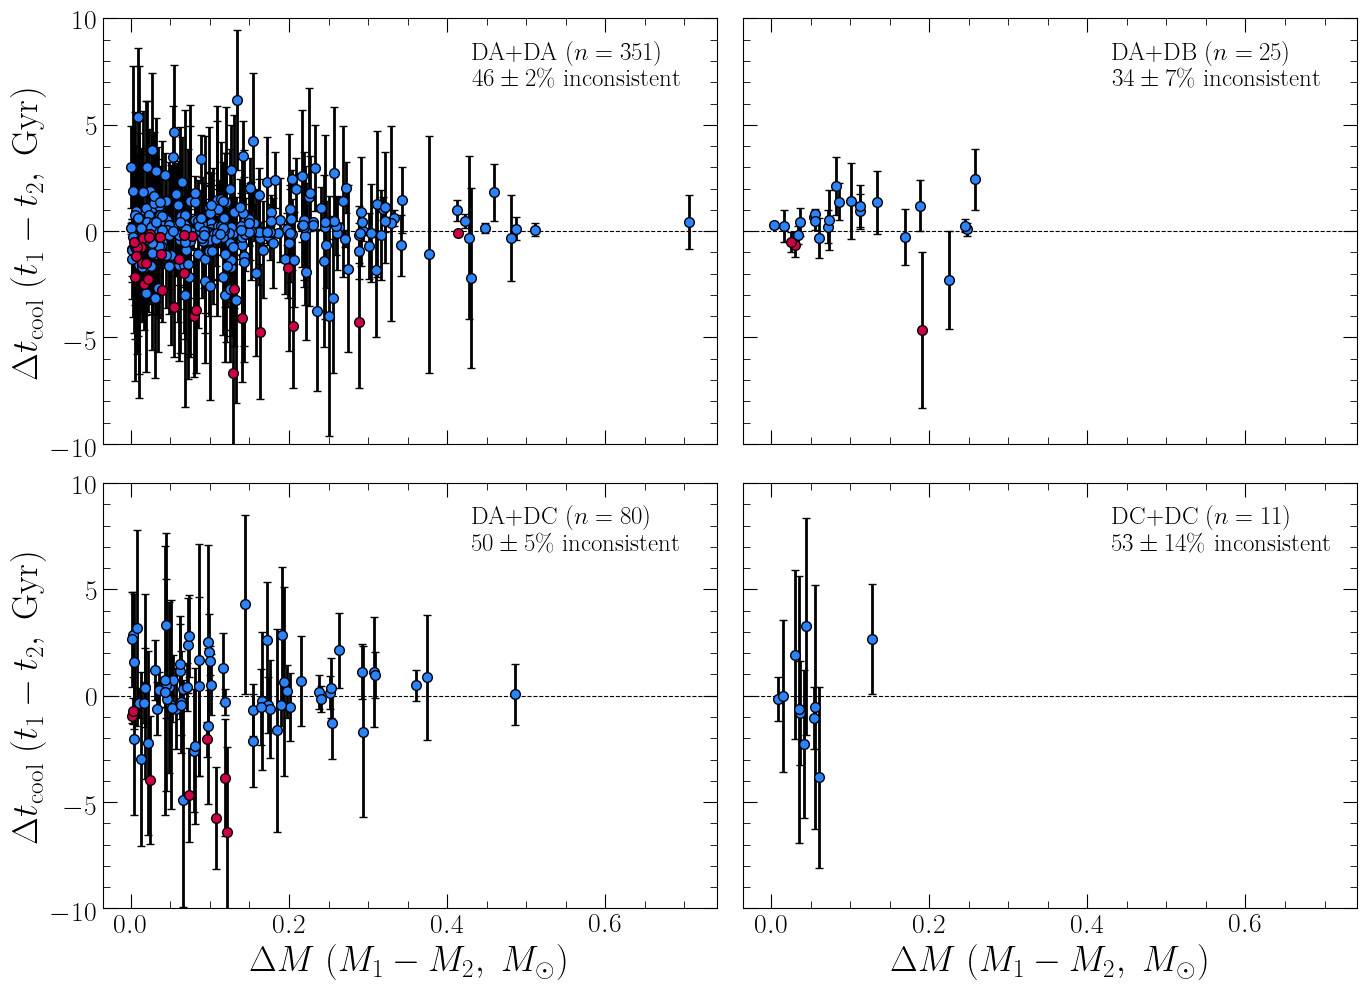

In [8]:
def inconsistency_stats(df, valid_mask, panel_mask, dt_col, e_dt_col, one_sided,
                        n_mc=10000, random_state=None):
    """Fraction 1σ inconsistent with τ_1 > τ_2, i.e. dt + e_dt < 0."""
    rng = np.random.default_rng(random_state)

    sel = df[valid_mask & panel_mask]
    if len(sel) == 0:
        return 0, np.nan, np.nan, np.nan

    dt = sel[dt_col].values
    edt = sel[e_dt_col].values

    # --- Original hard classification ---
    if not one_sided:
        inconsist = dt + edt < 0
    else:
        inconsist = np.abs(dt) - edt > 0

    f_inc = inconsist.mean()

    # --- Monte Carlo ---
    # Draw shape: (n_mc, n_points)
    draws = rng.normal(loc=dt, scale=edt, size=(n_mc, len(dt)))
    frac_mc = (draws < 0).mean(axis=1)
    f_mc_mean = frac_mc.mean()
    f_mc_std = frac_mc.std()
    return len(sel), inconsist, f_inc, f_mc_mean, f_mc_std


def plot_dm_dt(pairs, valid_mask, panel_masks, dt_col, e_dt_col, ylabel, one_sided=False):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
    axes = axes.flatten()

    for ax, (label, panel_mask) in zip(axes, panel_masks.items()):
        sel = pairs[valid_mask & panel_mask]
        n_tot, inconsist, f_inc, f_mc_mean, f_mc_std = inconsistency_stats(
            pairs, valid_mask, panel_mask, dt_col, e_dt_col, one_sided
        )

        if len(sel) == 0:
            ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, ha='center')
            ax.set_title(label)
            continue

        ax.errorbar(
            sel.loc[~inconsist, 'dM'], sel.loc[~inconsist, dt_col], yerr=sel.loc[~inconsist, e_dt_col],
            fmt="o", markeredgecolor="k", ecolor="k", lw=2, capsize=3, markersize=7, color="#2b83ff",
            label='Consistent'
        )
        ax.errorbar(sel.loc[inconsist, 'dM'], sel.loc[inconsist, dt_col], yerr=sel.loc[inconsist, e_dt_col],
            fmt="o", markeredgecolor="k", ecolor="k", lw=2, capsize=3, markersize=7, color="#ce0048",
            label='Inconsistent'
        )

        ax.axhline(0, color='k', lw=0.8, ls='--', zorder=1)

        ax.text(0.60, 0.95,
                f'{label} ($n = {n_tot}$)\n${100*f_mc_mean:.0f}\\pm{100*f_mc_std:.0f}\\%$ inconsistent',
                transform=ax.transAxes, va='top', fontsize=18,
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.0))
        
        
    axes[2].set_xlabel(r'$\Delta M\ (M_1 - M_2,\ M_\odot)$')
    axes[3].set_xlabel(r'$\Delta M\ (M_1 - M_2,\ M_\odot)$')

    axes[0].set_ylabel(ylabel)
    axes[2].set_ylabel(ylabel)

    axes[0].set_ylim(-10, 10)

    plt.tight_layout()
    plt.show()


plot_dm_dt(
    pairs, valid_cool, panel_masks,
    dt_col='dtcool', e_dt_col='e_dtcool',
    ylabel=r'$\Delta t_\mathrm{cool}\ (t_1 - t_2,\ \mathrm{Gyr})$',
    one_sided=False
)

In [9]:
pairs.keys()

Index(['source_id1', 'source_id2', 'R_chance_align', 'mass_1', 'mass_hi_1',
       'mass_lo_1', 'teff_best_1', 'log_age_cool_1', 'log_age_cool_hi_1',
       'log_age_cool_lo_1', 'log_age_1', 'log_age_hi_1', 'log_age_lo_1',
       'SpType_1', 'mass_2', 'mass_hi_2', 'mass_lo_2', 'teff_best_2',
       'log_age_cool_2', 'log_age_cool_hi_2', 'log_age_cool_lo_2', 'log_age_2',
       'log_age_hi_2', 'log_age_lo_2', 'SpType_2', 't_log_age_cool_1',
       't_log_age_cool_hi_1', 't_log_age_cool_lo_1', 'e_t_log_age_cool_1',
       't_log_age_1', 't_log_age_hi_1', 't_log_age_lo_1', 'e_t_log_age_1',
       'e_mass_1', 't_log_age_cool_2', 't_log_age_cool_hi_2',
       't_log_age_cool_lo_2', 'e_t_log_age_cool_2', 't_log_age_2',
       't_log_age_hi_2', 't_log_age_lo_2', 'e_t_log_age_2', 'e_mass_2', 'dM',
       'e_dM', 'd_log_age_cool', 'e_d_log_age_cool', 'd_log_age',
       'e_d_log_age', 'dtcool', 'e_dtcool', 'dtot', 'e_dtot'],
      dtype='object')

## Total age differences

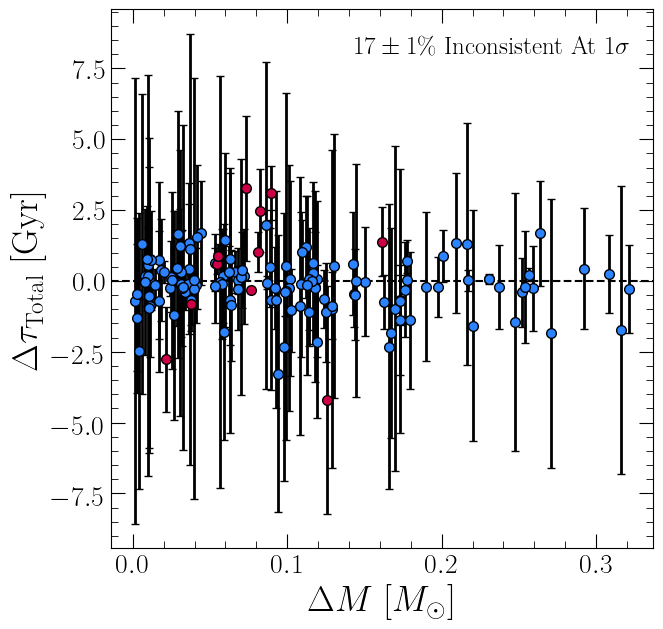

In [10]:
consistent = (np.abs(pairs.dtot) - pairs.e_dtot) < 0

rng = np.random.default_rng(None)
dt, edt = pairs.loc[:, "dtot"].to_numpy(), pairs.loc[:, "e_dtot"].to_numpy()

draws = rng.normal(loc=dt, scale=edt, size=(1000, len(dt)))
frac_mc = (np.abs(draws) / edt[None,:] < 1).mean(axis=1)
f_mc_mean = frac_mc.mean()
f_mc_std = frac_mc.std()

plt.errorbar(pairs.loc[consistent, "dM"], pairs.loc[consistent,"dtot"], yerr=pairs.loc[consistent,"e_dtot"],
             fmt="o", markeredgecolor="k", ecolor="k", lw=2, capsize=3, markersize=7, color="#2b83ff",
             label='Inconsistent')
plt.errorbar(pairs.loc[~consistent, "dM"], pairs.loc[~consistent,"dtot"], yerr=pairs.loc[~consistent,"e_dtot"],
             fmt="o", markeredgecolor="k", ecolor="k", lw=2, capsize=3, markersize=7, color="#ce0048",
             label='Inconsistent')
plt.axhline(0, c="k", ls="--")

plt.text(0.45, 0.95,
    f'${100*f_mc_mean:.0f}\\pm{100*f_mc_std:.0f}\\%$ Inconsistent At $1\\sigma$',
    transform=plt.gca().transAxes, va='top', fontsize=18,
    bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.0)
)

plt.xlabel(r"$\Delta M$ [$M_\odot$]")
plt.ylabel(r"$\Delta \tau_\text{Total}$ [Gyr]")

plt.savefig("figures/inconsistent_ages.pdf")

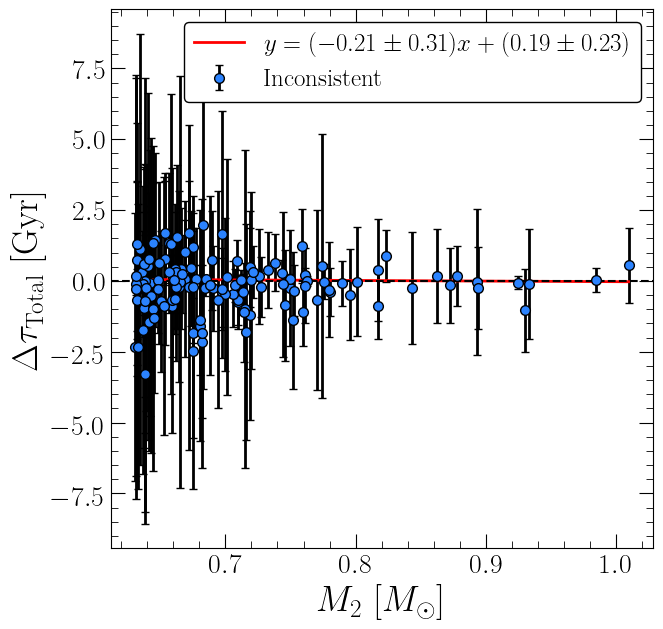

In [11]:
x = pairs.loc[consistent, "mass_2"].values
y = pairs.loc[consistent, "dtot"].values
yerr = pairs.loc[consistent, "e_dtot"].values

# Weights
w = 1 / yerr

# Fit with covariance
coeffs, cov = np.polyfit(x, y, deg=1, w=w, cov=True)
slope, intercept = coeffs

# Uncertainties
slope_err = np.sqrt(cov[0, 0])
intercept_err = np.sqrt(cov[1, 1])

# Fit line
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = slope * x_fit + intercept

# Plot data
plt.errorbar(
    x, y, yerr=yerr,
    fmt="o", markeredgecolor="k", ecolor="k", lw=2, capsize=3,
    markersize=7, color="#2b83ff", label='Inconsistent'
)

# Fit line with uncertainties in legend
plt.plot(
    x_fit, y_fit, color="red", lw=2,
    label=fr'$y = ({slope:.2f} \pm {slope_err:.2f})x + ({intercept:.2f} \pm {intercept_err:.2f})$'
)

plt.axhline(0, c="k", ls="--")

# Bias text (unchanged)
bias = np.mean(y)
sgbias = np.mean(y / yerr)

plt.text(
    0.45, 0.95,
    f'bias={bias:1.2f} Gyr ({sgbias:1.2f} sigma)',
    transform=plt.gca().transAxes, va='top', fontsize=18,
    bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.0)
)

plt.xlabel(r"$M_2$ [$M_\odot$]")
plt.ylabel(r"$\Delta \tau_\text{Total}$ [Gyr]")
plt.legend()

(0.6, 1.1)

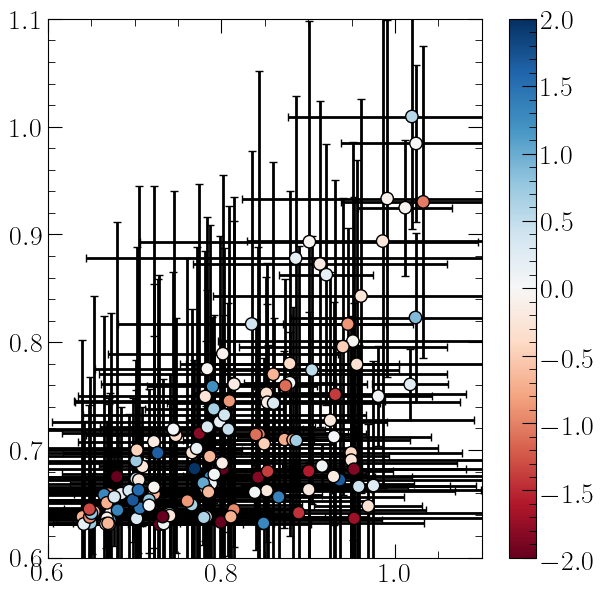

In [12]:
plt.errorbar(pairs.loc[consistent, "mass_1"], pairs.loc[consistent, "mass_2"],
    xerr=pairs.loc[consistent, "e_mass_1"], yerr=pairs.loc[consistent, "e_mass_2"],
    fmt="o", markeredgecolor="k", ecolor="k", lw=2, capsize=3, markersize=1, color="#2b83ff",
)
plt.scatter(pairs.loc[consistent, "mass_1"], pairs.loc[consistent, "mass_2"],
    c=pairs.loc[consistent, "dtot"], zorder=10, vmin=-2, vmax=2, edgecolor="k", s=80,
    cmap="RdBu"
)
plt.colorbar()

plt.xlim(0.60, 1.1)
plt.ylim(0.60, 1.1)